In [1]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import IncrementalPCA
from torchvision.models.feature_extraction import create_feature_extractor
import torch
import cv2
import joblib
import matplotlib.pyplot as plt
import time
from einops import rearrange
from IPython.display import clear_output
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])
from useful_stuff.general_utils.utils import print_wise, is_empty, get_device
from useful_stuff.image_processing.utils import get_video_dimensions, read_video
from useful_stuff.image_processing.computational_models import get_relevant_output_layers, imgANN
# from image_processing.utils import concatenate_frames_batch, shuffle_frames
from image_processing.gaze_dep_models import preprocess_batch, extract_center_patches, sample_random_patches, capture_1917_movie_runs, extract_features_1917_movie, ipca_movie_patches, save_ipca_patch


In [22]:
from dataclasses import dataclass, field

device = 'mps'
@dataclass
class Cfg:
    sq_size = 384
    input_size = 384
    secs_to_skip = 5
    batch_size = 100
    patches_per_frame = 3
    frames_step = 3 # every how many frames we want to take a sample (due to high temporal autocorrelation we can skip)
    patches_overhead_sampling = 2 # how many patches we want more than the images we're gonna pass to the model (to avoid proper shuffling)
    tot_patches = 3
    n_components = 1000
    layer_idx = 23
    model_name = 'dino_v3_l'
    pkg = 'hf'
    sub_num = 4
    repetition = 0
    neu_fs = 100
    sq_side = 384
    run = 2
    jump = 20
    layers_to_viz = [1, 9, 19]
    pooling = "all"
    model_url = "facebook/dinov3-vitl16-pretrain-lvd1689m"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
mod_fs = config["movie_fs"]

In [3]:
# m = imgANN(cfg.model_name, cfg.pkg, cfg.pooling, repo_url=cfg.model_url, dtype=torch.float32)

In [4]:
# fn = save_ipca_patch(paths, cfg.model_name, layers[cfg.layer_idx], cfg.n_components, cfg.sq_size, cfg.pooling)
# print(fn)
# ipca_obj = joblib.load(fn)


In [31]:
from image_processing.gaze_dep_models import save_ANN_features, save_pixelwise_luminance
from project_specific_utils.dataloader import load_concat_regressout_mod
from scipy.io import loadmat
import h5py
m = []
for i in cfg.layers_to_viz:
    full_model_name = f"{cfg.model_name}_{layers[i]}"
    # m = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50,)
    m_temp = []
    for i_run in range(3,4):
        p = save_ANN_features(paths, full_model_name, cfg.sub_num, i_run, mod_fs, cfg.sq_side, cfg.n_components, cfg.pooling,)
        with h5py.File(p, "r") as f:
            m_temp.append(f["vecrep"][:][:,::cfg.jump])
    m_temp = np.concatenate(m_temp, 1)
    m.append(m_temp)

In [32]:
m_pix = []
for i_run in range(3,4):
    p_pix = save_pixelwise_luminance(paths, "pixelwise_luminance", cfg.sub_num, i_run, mod_fs, 250,*(50,))
    with h5py.File(p_pix, "r") as f:
        m_pix_temp = f["vecrep"][:][:,::cfg.jump]
    m_pix_reshaped = m_pix_temp.reshape(50, 50, 3,m_pix_temp.shape[1], order='F')
    m_pix.append(m_pix_reshaped)
m_pix = np.concatenate(m_pix, axis=-1)

In [25]:
from sklearn.manifold import TSNE
m_tsne = []
for m_l in m:
    X_tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=0
    ).fit_transform(m_l[:200, :].T)
    m_tsne.append(X_tsne)

In [33]:
import umap
m_umap = []
for m_l in m:
    X_umap = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=.1,
        random_state=0,
    ).fit_transform(m_l[:1000, :].T)
    m_umap.append(X_umap)

/Users/tizianocausin/Desktop/project1917-26/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/tizianocausin/Desktop/project1917-26/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/tizianocausin/Desktop/project1917-26/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


0

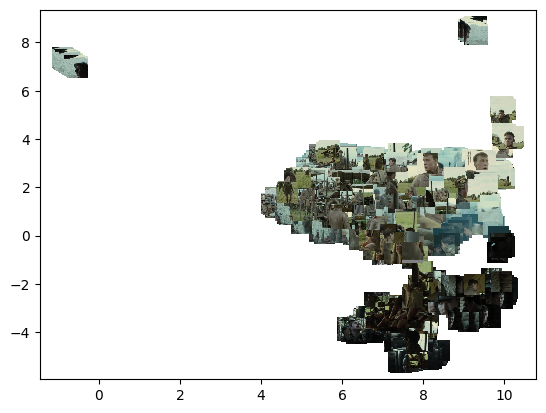

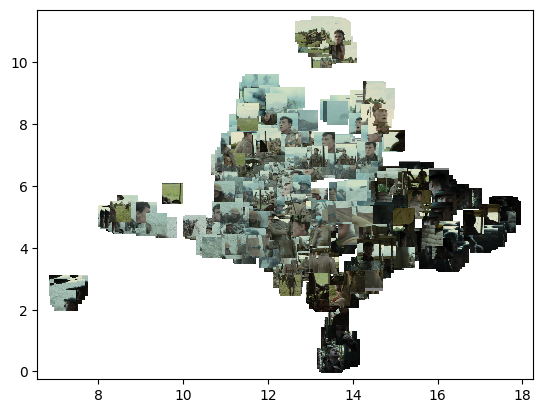

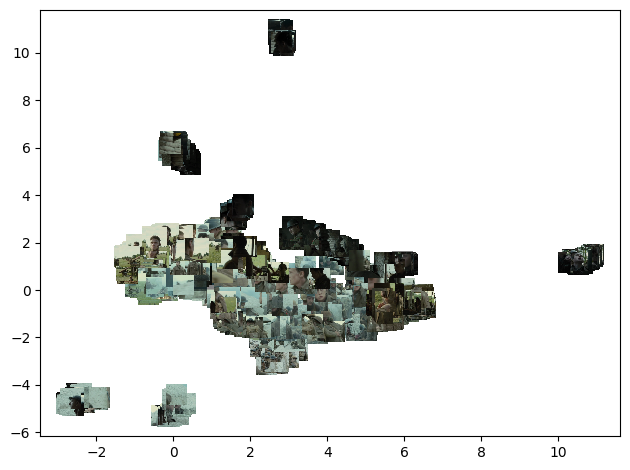

In [34]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


for idx, idx_l in enumerate(cfg.layers_to_viz):
    fig, ax = plt.subplots()
    pts = m_umap[idx][:, :].T
    ax.scatter(pts[0, :], pts[1, :], s=5, alpha=0.2)

    n = min(pts.shape[1], m_pix.shape[-1])
    for t in range(n):
        img = m_pix[..., t]
        ab = AnnotationBbox(
            OffsetImage(img, zoom=0.3, alpha=1),
            (pts[0, t], pts[1, t]),
            frameon=False,
            # pad=0,
            # bboxprops=dict(
            #     edgecolor='black',
            #     linewidth=1
            # )
        )
        # ab.patch.set_edgecolor('black')
        # ab.patch.set_linewidth(0.5)
        ax.add_artist(ab)

    # ax[idx].set_title(f"layer {idx_l}")
    # ax[idx].set_xlabel("PC1")
    # ax[idx].set_ylabel("PC2")

plt.tight_layout()
os.system('afplay /System/Library/Sounds/Ping.aiff')
    # ax[idx].scatter(m[idx][0, :], m[idx][1, :])


In [230]:
from sklearn.manifold import TSNE

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=0
).fit_transform(m[2][:100, :].T)

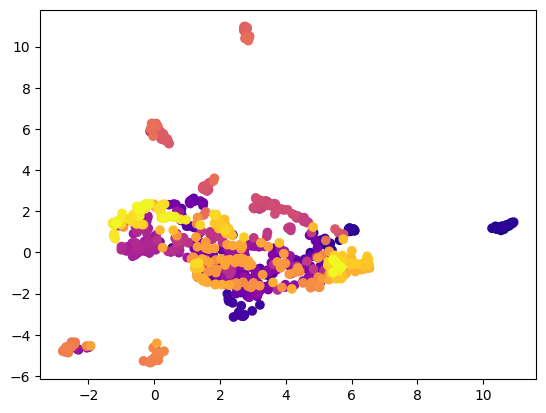

In [40]:
plt.scatter(m_umap[2][:, 0], m_umap[2][:, 1], c=np.arange(m_umap[2].shape[0]), cmap='plasma')

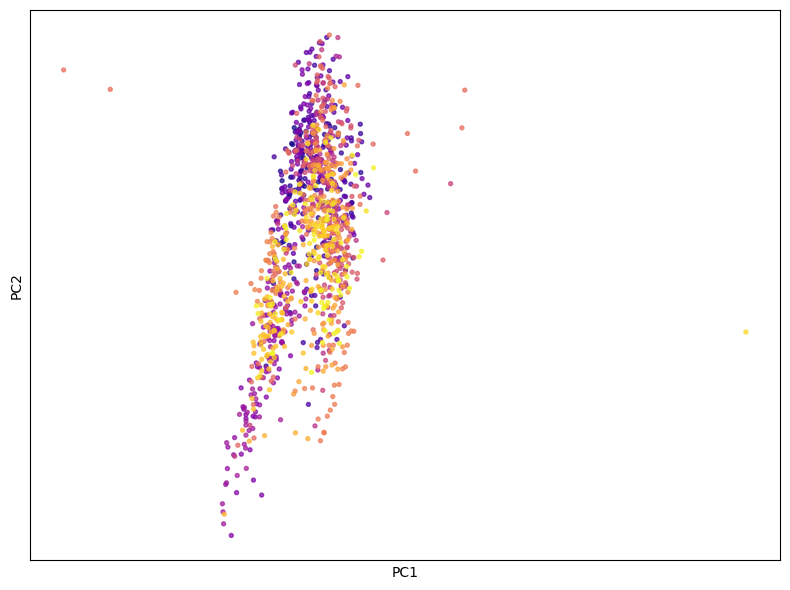

In [214]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()#111, projection="3d")
pts = m[0]
ax.scatter(pts[0, :], pts[1, :], c=np.arange(pts.shape[1]), s=8, alpha=0.7, cmap='plasma')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")
ax.set_xticks([])
ax.set_yticks([])
# ax.set_zticks([])
plt.tight_layout()
plt.show()

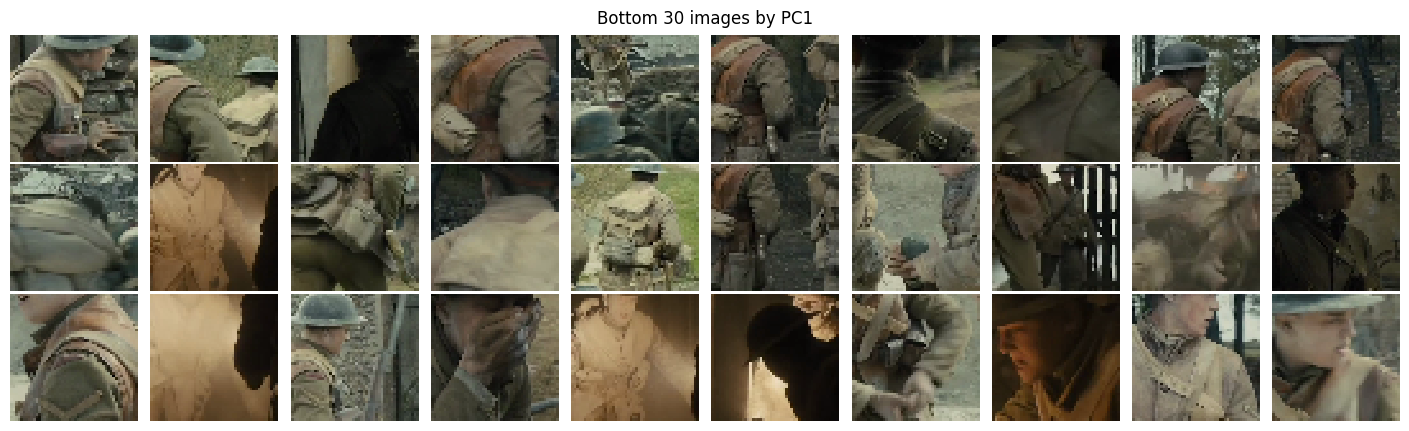

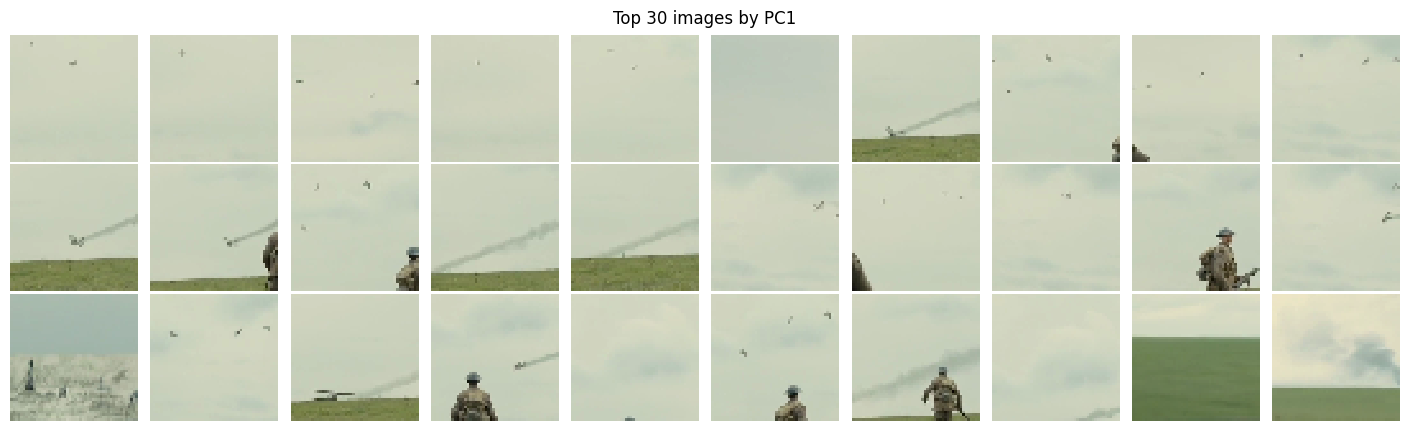

In [176]:
pc1 = m[2][0, :]

order = np.argsort(pc1)
bottom_idx = order[:30]
top_idx = order[-30:][::-1]

def plot_tiled(indices, title, ncols=10):
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(1.4 * ncols, 1.4 * nrows),
        gridspec_kw={"wspace": 0.02, "hspace": 0.02}
    )
    axes = np.array(axes).reshape(-1)

    for k, i in enumerate(indices):
        axes[k].imshow(m_pix_reshaped[:, :, :, i], interpolation="nearest")
        axes[k].axis("off")

    for k in range(n, len(axes)):
        axes[k].axis("off")

    fig.suptitle(title, fontsize=12)
    plt.subplots_adjust(left=0, right=1, top=0.92, bottom=0, wspace=0.02, hspace=0.02)
    plt.show()

plot_tiled(bottom_idx, "Bottom 30 images by PC1")
plot_tiled(top_idx, "Top 30 images by PC1")

In [36]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
m.create_forward_hook([layers[cfg.layer_idx]])
torch.cuda.empty_cache()
caps_list = capture_1917_movie_runs(paths)
fps = caps_list[0].get(cv2.CAP_PROP_FPS)
tot_frames = []
for start_f in [1500,]:
    start_s = start_f/fps
    for cap in caps_list:
        end_f = start_f+500
        end_s = end_f/fps
        v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
        v = v[::cfg.frames_step*10]
        v = extract_center_patches(v, cfg.sq_size)
        if tot_frames is None:
            tot_frames = v
        else:
            tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
        # end if tot_frames is None:
    chunk = sample_random_patches(tot_frames, 100)
preproc_chunk = preprocess_batch(chunk, cfg.input_size, device=device)

with torch.no_grad():
    m.model(preproc_chunk)


pts = m.features[layers[cfg.layer_idx]].detach().cpu().numpy() @ ipca_obj.components_.T

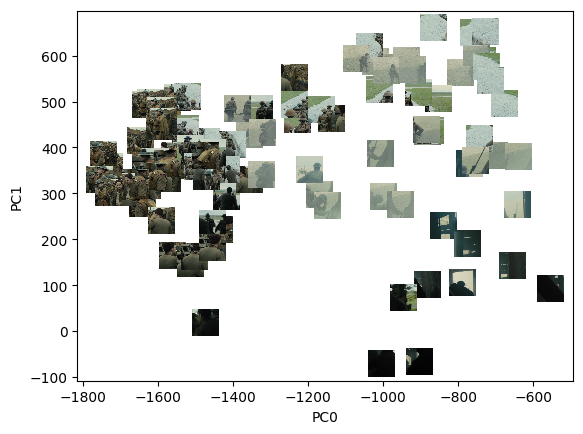

In [37]:
fig, ax = plt.subplots()

# scatter points (optional, for reference)
dims = (0,1)
ax.scatter(pts[:, dims[0]], pts[:, dims[1]])
ax.set_xlabel(f"PC{dims[0]}")
ax.set_ylabel(f"PC{dims[1]}")

# overlay images
for i in range(pts.shape[0]):
    # ensure image is in (H, W, C) and in [0,1] or [0,255]
    x = pts[i, dims[0]]
    y = pts[i, dims[1]]
    c = chunk[i, :].detach().cpu().numpy()
    # m = np.abs(c).max()
    # c_min, c_max = c.min(), c.max()
    # img = (c - c_min) / (c_max - c_min + 1e-8)
    # img = c.transpose(1,2,0)
    image = OffsetImage(c, zoom=0.05, alpha=1)

    ab = AnnotationBbox(image, (x, y), frameon=False)
    ax.add_artist(ab)
plt.show()

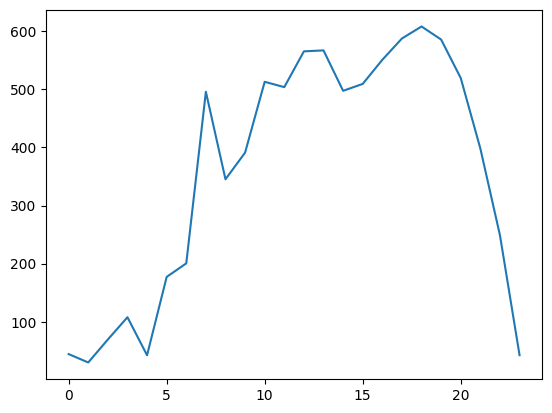

In [ ]:
prs = []
for i in range(len(layers)):
    fn = save_ipca_patch(paths, cfg.model_name, layers[i], cfg.n_components, cfg.sq_size, cfg.pooling)
    ipca_obj = joblib.load(fn)
    pr = (np.sum(ipca_obj.explained_variance_))**2 / np.sum(ipca_obj.explained_variance_**2)
    prs.append(pr)

plt.plot(prs, marker="o")
# plt.plot(np.cumsum(ipca_obj.explained_variance_ratio_))
# fn = save_ipca_patch(paths, cfg.model_name, layers[23], cfg.n_components, cfg.sq_size, cfg.pooling)
# ipca_obj = joblib.load(fn)
# pr = (np.sum(ipca_obj.explained_variance_))**2 / np.sum(ipca_obj.explained_variance_**2)
# print(pr)
# plt.plot(np.cumsum(ipca_obj.explained_variance_ratio_))

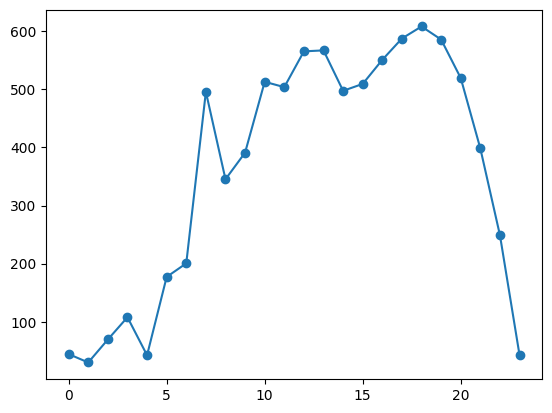

In [205]:
plt.plot(prs, marker="o")

In [147]:
pr = (np.sum(ipca_obj.explained_variance_))**2 / np.sum(ipca_obj.explained_variance_**2)
print(pr)

42.59226528786883


# TODO do this also for already extracted and projected features